# CAPEN-Llama-att attention γ on hierarchical TopTagging

Estimate pre-softmax temperatures $\gamma_{rs}$ as **mean nonempty row degrees** of the supports that **CAPEN-Llama-att** actually uses on the hierarchical cache:

| Support | Construction |
|---|---|
| $M_{11}$ | all-to-all among valid **nodes** (particles + virtuals) |
| $M_{12}$, $M_{21}$ | incidence (edge $\leftrightarrow$ node) |
| $M_{22}$ | all-to-all among **hyperedges only** (incidence degree $>2$) |

That $M_{22}$ is *not* the dense edge–edge support of vanilla CAPEN-Llama. Pairwise kNN / vn_link slots are identity there.

Default cache: `processed/hier_k8_eps0p08_ms2_vn1_ve1_mdb32_pint/n128/`.

Training jobs estimate these γ values automatically (same supports, including
`--hyperedge-only`). This notebook is for inspecting the degree histograms.

Run with the `mamba-env` kernel. First code cell forces CPU so `import torch` does not hang probing GPUs on a login node.

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path

# Login nodes: prevent torch from probing CUDA (can hang the kernel).
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib.pyplot as plt
import numpy as np
import torch

REPO_CANDIDATES = [
    Path("/home/jdezoort/coupled-particle-edge-networks"),
    Path.cwd().resolve(),
    Path.cwd().resolve().parent,
]
REPO = next(p for p in REPO_CANDIDATES if (p / "src" / "cpen").is_dir())
for p in (REPO, REPO / "src"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from cpen.utils.attention_temperature import (
    AttentionGammas,
    _build_attention_supports,
    _dense_incidence_from_coo_payload,
    support_row_degrees,
)
from cpen.utils.hier_graph_cache import (
    hier_graph_cache_available,
    processed_hier_split_dir,
)
from cpen.utils.toptagging import normalize_data_root

DATA_ROOT = normalize_data_root("/scratch/gpfs/BHANIN/jdezoort/datasets/toptagging")
K = 8
EPS = 0.08
MIN_SAMPLES = 2
N_VIRTUAL_NODES = 1
N_VIRTUAL_EDGES = 1
MAX_DBSCAN_EDGES = 32
NUM_PARTICLES = 128
SPLIT = "train"
N_JETS = 512
BATCH_SIZE = 16  # dense incidence is M×N; keep this modest on a login node
SEED = 42
ALL_TO_ALL_11 = True  # CAPEN-Llama / CAPEN-Llama-att
HYPEREDGE_M22_ONLY = True  # CAPEN-Llama-att default

HIER_KW = dict(
    k=K,
    eps=EPS,
    min_samples=MIN_SAMPLES,
    n_virtual_nodes=N_VIRTUAL_NODES,
    n_virtual_edges=N_VIRTUAL_EDGES,
    max_dbscan_edges=MAX_DBSCAN_EDGES,
    num_particles=NUM_PARTICLES,
)

print(f"REPO={REPO}")
print(f"DATA_ROOT={DATA_ROOT} exists={DATA_ROOT.is_dir()}")
print(f"hier k={K} eps={EPS} vn={N_VIRTUAL_NODES} ve={N_VIRTUAL_EDGES} mdb={MAX_DBSCAN_EDGES}")

REPO=/home/jdezoort/coupled-particle-edge-networks
DATA_ROOT=/scratch/gpfs/BHANIN/jdezoort/datasets/toptagging exists=True
hier k=8 eps=0.08 vn=1 ve=1 mdb=32


In [2]:
assert hier_graph_cache_available(
    data_root=str(DATA_ROOT),
    split=SPLIT,
    **HIER_KW,
), f"Missing hierarchical cache under {DATA_ROOT}"

cache_dir = processed_hier_split_dir(DATA_ROOT, **HIER_KW)
meta = json.loads((cache_dir / "meta.json").read_text())
t0 = time.time()
payload = torch.load(
    cache_dir / f"{SPLIT}.pt",
    map_location="cpu",
    mmap=True,
    weights_only=False,
)
print(f"mmap open in {time.time() - t0:.2f}s")

n_total = int(payload["labels"].size(0))
rng = np.random.default_rng(SEED)
pick = rng.choice(n_total, size=min(N_JETS, n_total), replace=False)

print(f"cache: {cache_dir}")
print(
    f"meta: tag={meta.get('hierarchical_construction_tag')} "
    f"n={meta.get('num_particles')} storage={meta.get('storage')}"
)
print(f"sampling {len(pick):,} / {n_total:,} {SPLIT} jets")

mmap open in 0.50s
cache: /scratch/gpfs/BHANIN/jdezoort/datasets/toptagging/processed/hier_k8_eps0p08_ms2_vn1_ve1_mdb32/n128
meta: tag=hier_k8_eps0p08_ms2_vn1_ve1_mdb32 n=128 storage=sparse-bool-incidence-v1
sampling 512 / 1,211,000 train jets


In [3]:
def hyperedge_m22(s_bool: torch.Tensor, edge_mask: torch.Tensor | None) -> torch.Tensor:
    """All-to-all among incidence-degree > 2 (CAPEN-Llama-att $M_{22}$)."""
    is_hyper = s_bool.to(dtype=torch.float32).sum(dim=-1) > 2
    if edge_mask is not None:
        is_hyper = is_hyper & edge_mask.to(device=is_hyper.device, dtype=torch.bool)
    return is_hyper.unsqueeze(-1) & is_hyper.unsqueeze(-2)


degree_lists: dict[str, list[np.ndarray]] = {k: [] for k in ("11", "12", "21", "22")}
readout_deg: list[np.ndarray] = []
n_batches = (len(pick) + BATCH_SIZE - 1) // BATCH_SIZE
t0 = time.time()

for b, start in enumerate(range(0, len(pick), BATCH_SIZE)):
    idx = pick[start : start + BATCH_SIZE]
    idx_t = torch.as_tensor(idx, dtype=torch.long)
    node_mask = payload["node_mask"][idx_t].bool()
    edge_mask = payload["edge_mask"][idx_t].bool()
    if "incidence" in payload:
        s_bool = payload["incidence"][idx_t].bool()
    else:
        s_bool = _dense_incidence_from_coo_payload(payload, idx_t)

    m_11, m_21, m_12, m_22_full = _build_attention_supports(
        s_bool,
        node_mask,
        all_to_all_particle_attention=ALL_TO_ALL_11,
    )
    m_22 = hyperedge_m22(s_bool, edge_mask) if HYPEREDGE_M22_ONLY else m_22_full

    for key, support in (("11", m_11), ("12", m_12), ("21", m_21), ("22", m_22)):
        deg = support_row_degrees(support).reshape(-1).detach().cpu().numpy()
        degree_lists[key].append(deg[deg >= 1].astype(np.float64))

    # Class-token KV: valid nodes + hyperedges (matches readout mask).
    is_hyper = s_bool.to(dtype=torch.float32).sum(dim=-1) > 2
    is_hyper = is_hyper & edge_mask
    n_kv = node_mask.sum(dim=-1) + is_hyper.sum(dim=-1)
    readout_deg.append(n_kv.detach().cpu().numpy().astype(np.float64))

    del node_mask, edge_mask, s_bool, m_11, m_21, m_12, m_22, m_22_full, is_hyper, n_kv

    if (b + 1) == 1 or (b + 1) % 4 == 0 or (b + 1) == n_batches:
        print(f"  batch {b + 1}/{n_batches}  elapsed {time.time() - t0:.1f}s", flush=True)

summaries: dict[str, dict] = {}
means: dict[str, float] = {}
for key, chunks in degree_lists.items():
    vals = np.concatenate(chunks) if chunks else np.array([], dtype=np.float64)
    if vals.size == 0:
        summaries[key] = {
            "n_rows": 0,
            "mean": 1.0,
            "std": 0.0,
            "min": 1.0,
            "max": 1.0,
            "median": 1.0,
            "degrees": vals,
        }
        means[key] = 1.0
    else:
        summaries[key] = {
            "n_rows": int(vals.size),
            "mean": float(vals.mean()),
            "std": float(vals.std()),
            "min": float(vals.min()),
            "max": float(vals.max()),
            "median": float(np.median(vals)),
            "degrees": vals,
        }
        means[key] = float(vals.mean())

gammas = AttentionGammas(
    gamma_11=means["11"],
    gamma_12=means["12"],
    gamma_21=means["21"],
    gamma_22=means["22"],
)

print("\nRecommended --attention-normalization gamma values:")
print(
    f"  --gamma-11 {gammas.gamma_11:.4g} "
    f"--gamma-12 {gammas.gamma_12:.4g} "
    f"--gamma-21 {gammas.gamma_21:.4g} "
    f"--gamma-22 {gammas.gamma_22:.4g}"
)
print()
for rel, s in summaries.items():
    print(
        f"M_{rel}: n_rows={s['n_rows']:,}  "
        f"mean={s['mean']:.3f}  median={s['median']:.3f}  "
        f"std={s['std']:.3f}  min={s['min']:.0f}  max={s['max']:.0f}"
    )

kv = np.concatenate(readout_deg) if readout_deg else np.array([], dtype=np.float64)
if kv.size:
    print(
        f"\nclass-token KV size (nodes + hypers):  "
        f"mean={kv.mean():.3f}  median={np.median(kv):.3f}  "
        f"min={kv.min():.0f}  max={kv.max():.0f}"
    )
    print("(not a CLI flag — readout uses the same μP 1/√D scale as the trunk decoder)")

  batch 1/32  elapsed 8.5s
  batch 4/32  elapsed 8.9s
  batch 8/32  elapsed 9.5s
  batch 12/32  elapsed 10.3s
  batch 16/32  elapsed 10.9s
  batch 20/32  elapsed 11.5s
  batch 24/32  elapsed 12.0s
  batch 28/32  elapsed 12.5s
  batch 32/32  elapsed 13.2s

Recommended --attention-normalization gamma values:
  --gamma-11 55.03 --gamma-12 2.045 --gamma-21 18.32 --gamma-22 4.992

M_11: n_rows=25,321  mean=55.026  median=54.000  std=16.481  min=10  max=105
M_12: n_rows=226,824  mean=2.045  median=2.000  std=2.506  min=1  max=104
M_21: n_rows=25,321  mean=18.319  median=18.000  std=6.207  min=9  max=104
M_22: n_rows=2,196  mean=4.992  median=5.000  std=1.742  min=1  max=9

class-token KV size (nodes + hypers):  mean=53.744  median=54.000  min=12  max=114
(not a CLI flag — readout uses the same μP 1/√D scale as the trunk decoder)


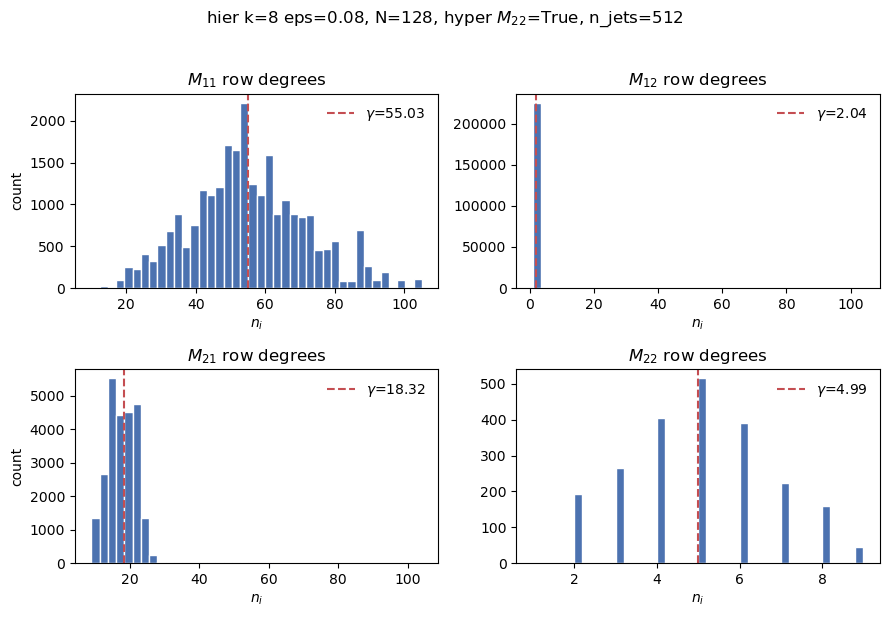

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6), sharey=False)
for ax, rel in zip(axes.ravel(), ("11", "12", "21", "22")):
    vals = summaries[rel]["degrees"]
    ax.hist(
        vals,
        bins=min(40, max(5, int(np.sqrt(max(len(vals), 1))))),
        color="#4C72B0",
        edgecolor="white",
    )
    ax.axvline(
        summaries[rel]["mean"],
        color="#C44E52",
        ls="--",
        lw=1.5,
        label=rf"$\gamma$={summaries[rel]['mean']:.2f}",
    )
    ax.set_title(rf"$M_{{{rel}}}$ row degrees")
    ax.set_xlabel(r"$n_i$")
    ax.legend(frameon=False)
axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
fig.suptitle(
    f"hier k={K} eps={EPS}, N={NUM_PARTICLES}, "
    f"hyper $M_{{22}}$={HYPEREDGE_M22_ONLY}, n_jets={len(pick)}",
    y=1.02,
)
fig.tight_layout()
plt.show()

## Training estimates these automatically

Do **not** paste `--gamma-11/12/21/22` into the slurm. Each job with
`--attention-normalization gamma` estimates $\gamma_{rs}$ from the hierarchical
cache **before fit**, using the same supports as training (all-to-all $M_{11}$,
incidence $M_{12}/M_{21}$, hyperedge-only $M_{22}$, drop-kNN when
`--hyperedge-only`). Values are printed to Slurm stdout and written into the
run parquet. Opt out with `--no-estimate-gamma-rs` plus explicit flags.

This notebook is for inspecting the degree histograms, not for supplying CLI
numbers. $\gamma_{11} \approx \langle N_{\mathrm{valid}}\rangle$ (particles +
virtuals). $\gamma_{22}$ is the typical **hyperedge** count, not the pairwise
edge count.

```bash
sbatch scans/jets/test_capen_llama_att_toptagging_hier.slurm
```

In [ ]:
f